In [34]:

!pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)



In [35]:
orders = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\raw\orders.csv')
order_products = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\raw\order_products__prior.csv')
products = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\raw\products.csv')
pincode_df  = pd.read_csv(r'F:\projectss\personal\blinkit_project\data\raw\5c2f62fe-5afa-4119-a499-fec9d604d5bd.csv')



In [36]:
pincode_df.columns

Index(['circlename', 'regionname', 'divisionname', 'officename', 'pincode',
       'officetype', 'delivery', 'district', 'statename', 'latitude',
       'longitude'],
      dtype='object')

In [37]:
pincode_df[pincode_df['regionname'] =='Ahmedabad HQ Region']

,circlename,regionname,divisionname,officename,pincode,officetype,delivery,district,statename,latitude,longitude
9793,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Bakrol BO,382210,BO,Delivery,AHMADABAD,GUJARAT,23.029651,72.626689
9794,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Kubadthal BO,382430,BO,Delivery,AHMADABAD,GUJARAT,23.033567,72.758744
9795,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Kujad BO,382430,BO,Delivery,AHMADABAD,GUJARAT,23.060085,72.711379
9796,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Pardhol BO,382330,BO,Delivery,AHMADABAD,GUJARAT,23.095606,72.726643
9797,Gujarat Circle,Ahmedabad HQ Region,Ahmedabad City Division,Girmatha BO,382425,BO,Delivery,AHMADABAD,GUJARAT,22.877825,72.551355
...,...,...,...,...,...,...,...,...,...,...,...
161712,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Lusadia SO,383251,PO,Delivery,ARVALLI,GUJARAT,23.6899840,73.4652630
161713,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Malpur SO,383345,PO,Delivery,ARVALLI,GUJARAT,23.3589444,73.4647778
161714,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Radhiwad SO,383270,PO,Delivery,SABAR KANTHA,GUJARAT,23.7312360,72.9841960
161715,Gujarat Circle,Ahmedabad HQ Region,Sabarkantha Division,Takatuka SO,383246,PO,Delivery,ARVALLI,GUJARAT,23.7985000,73.2901944


In [38]:
# search for anything related to ahmedabad in any column
mask = pincode_df.apply(
    lambda col: col.astype(str).str.upper().str.contains('AHMEDABAD', na=False)
).any(axis=1)

print(f"Rows mentioning Ahmedabad anywhere: {mask.sum()}")
print(pincode_df[mask][['officename','pincode','district','statename']].head(20))

Rows mentioning Ahmedabad anywhere: 2269
           officename  pincode      district statename
9793        Bakrol BO   382210     AHMADABAD   GUJARAT
9794     Kubadthal BO   382430     AHMADABAD   GUJARAT
9795         Kujad BO   382430     AHMADABAD   GUJARAT
9796       Pardhol BO   382330     AHMADABAD   GUJARAT
9797      Girmatha BO   382425     AHMADABAD   GUJARAT
9798         Vasai BO   382425     AHMADABAD   GUJARAT
9799      Geratpur BO   382435     AHMADABAD   GUJARAT
9800     Sagrosana BO   385001  BANAS KANTHA   GUJARAT
9801      Hasanpur BO   385001  BANAS KANTHA   GUJARAT
9802       Jalotra BO   385001  BANAS KANTHA   GUJARAT
9803        Sangra BO   385001  BANAS KANTHA   GUJARAT
9804       Karjoda BO   385001  BANAS KANTHA   GUJARAT
9805      Dhagadia BO   385110  BANAS KANTHA   GUJARAT
9806        Chatra BO   385320  BANAS KANTHA   GUJARAT
9807     Garambadi BO   385320  BANAS KANTHA   GUJARAT
9808     Jasanwada BO   385320  BANAS KANTHA   GUJARAT
9809        Soneth BO   

In [39]:
ahmedabad_df = pincode_df[
    pincode_df['district'].str.upper().str.contains('AHMADABAD', na=False)
].copy()

ahmedabad_df = ahmedabad_df.dropna(subset=['latitude', 'longitude'])
ahmedabad_df = ahmedabad_df.drop_duplicates(subset='pincode')

print(f"Total Ahmedabad pincodes found: {ahmedabad_df.shape[0]}")
print(ahmedabad_df[['pincode','officename','district','latitude','longitude']].head(15))

Total Ahmedabad pincodes found: 81
      pincode    officename   district    latitude   longitude
9793   382210     Bakrol BO  AHMADABAD   23.029651   72.626689
9794   382430  Kubadthal BO  AHMADABAD   23.033567   72.758744
9796   382330    Pardhol BO  AHMADABAD   23.095606   72.726643
9797   382425   Girmatha BO  AHMADABAD   22.877825   72.551355
9799   382435   Geratpur BO  AHMADABAD   22.920627   72.648634
9868   382225     Vautha BO  AHMADABAD  22.6700000  72.5400000
9872   382220     Adroda BO  AHMADABAD  22.8300000  72.3100000
9874   382463      Ambli BO  AHMADABAD  23.0300000  72.4800000
9877   382260  Chandisar BO  AHMADABAD  22.8000000  72.4900000
9881   382460     Jaliya BO  AHMADABAD  22.7300000  72.4800000
9885   382465   Buranpur BO  AHMADABAD  22.3900000  72.2300000
9890   382145   Balsasan BO  AHMADABAD  23.4200000  72.2800000
9892   382265      Virdi BO  AHMADABAD  22.6300000  72.5000000
9893   382240     Gangad BO  AHMADABAD  22.6900000  72.2800000
9895   382230     Bh

In [40]:
orders['user_id'].unique()
orders[orders['user_id']==206207]

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
3421002,2166133,206207,prior,1,6,19,NaN
3421003,1074448,206207,prior,2,0,10,1.00
3421004,1666077,206207,prior,3,2,15,23.00
3421005,2364140,206207,prior,4,6,14,4.00
3421006,2277235,206207,prior,5,3,20,30.00
3421007,1791139,206207,prior,6,4,11,8.00
3421008,85132,206207,prior,7,0,15,30.00
3421009,1060980,206207,prior,8,0,21,30.00
3421010,2099684,206207,prior,9,1,12,1.00
3421011,1357124,206207,prior,10,3,11,16.00


In [41]:
products[products['product_id']==46475]

,product_id,product_name,aisle_id,department_id
46474,46475,Chocolate Chip Cookie Dough Frozen Greek Yogur...,58,1


In [42]:
order_products[order_products['order_id']==206207]

,order_id,product_id,add_to_cart_order,reordered
1955165,206207,46475,1,1
1955166,206207,45548,2,0
1955167,206207,36923,3,1
1955168,206207,19348,4,1
1955169,206207,30958,5,0


In [43]:
print("=== Missing values in orders ===")
print(orders.isnull().sum())

print("\n=== Data types ===")
print(orders.dtypes)

print("\n=== Order stats ===")
print(f"Total orders      : {orders['order_id'].nunique():,}")
print(f"Total users       : {orders['user_id'].nunique():,}")
print(f"Total products    : {products['product_id'].nunique():,}")
print(f"Total order lines : {order_products.shape[0]:,}")

print("\n=== Days of week in data (0=Sat, 1=Sun) ===")
print(orders['order_dow'].value_counts().sort_index())

print("\n=== Hour distribution sample ===")
print(orders['order_hour_of_day'].describe())

=== Missing values in orders ===
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

=== Data types ===
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

=== Order stats ===
Total orders      : 3,421,083
Total users       : 206,209
Total products    : 49,688
Total order lines : 32,434,489

=== Days of week in data (0=Sat, 1=Sun) ===
order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
Name: count, dtype: int64

=== Hour distribution sample ===
count   3421083.00
mean         13.45
std           4.23
min           0.00
25%          10.00
50%          13.00
7

In [44]:
# manually pick 10 pincodes that represent real ahmedabad zones
TARGET_AREAS = {
    380009: 'Navrangpura',
    380015: 'Satellite',
    380051: 'Bodakdev',
    380006: 'Paldi',
    380013: 'Gota',
    380019: 'Vastrapur',
    380021: 'Maninagar',
    382210: 'Bakrol',
    382330: 'Naroda',
    382435: 'Bareja',
}

# manual fallback coords if pincode not in govt dataset
FALLBACK_COORDS = {
    380009: (23.0395, 72.5614),   # Navrangpura
    380015: (23.0204, 72.5070),   # Satellite
    380051: (23.0509, 72.5155),   # Bodakdev
    380006: (23.0035, 72.5823),   # Paldi
    380013: (23.1167, 72.5793),   # Gota
    380019: (23.0378, 72.5270),   # Vastrapur
    380021: (22.9950, 72.6119),   # Maninagar
    382210: (23.0297, 72.6267),   # Bakrol
    382330: (23.0951, 72.7267),   # Naroda
    382435: (22.9206, 72.6486),   # Bareja
}

selected_rows = []
for pincode, name in TARGET_AREAS.items():
    row = ahmedabad_df[ahmedabad_df['pincode'] == pincode]

    if not row.empty:
        # found in govt dataset — use real coords
        lat = pd.to_numeric(row['latitude'].values[0], errors='coerce')
        lon = pd.to_numeric(row['longitude'].values[0], errors='coerce')
        print(f"{pincode} {name} — found in govt data ({lat:.4f}, {lon:.4f})")
    else:
        # NOT found — use hardcoded fallback coords
        # IMPORTANT: keep the original pincode number — do NOT replace it
        lat, lon = FALLBACK_COORDS[pincode]
        print(f"{pincode} {name} — not in govt data, using fallback ({lat:.4f}, {lon:.4f})")

    selected_rows.append({
        'pincode'  : pincode,   # always keep original target pincode
        'area_name': name,
        'latitude' : lat,
        'longitude': lon,
    })

selected = pd.DataFrame(selected_rows)

print("\n=== Final selected pincodes ===")
print(selected)

# verify all 10 target pincodes are present
assert list(selected['pincode']) == list(TARGET_AREAS.keys()), \
    "Pincode mismatch — check above output"

print("\n All 10 target pincodes confirmed")

# save — this is the file used by the app
selected.to_csv(r'F:\projectss\personal\blinkit_project\data\external/selected_ahmedabad_pincodes.csv', index=False)


380009 Navrangpura — found in govt data (23.0472, 72.5528)
380015 Satellite — found in govt data (23.0268, 72.5233)
380051 Bodakdev — found in govt data (23.0048, 72.5209)
380006 Paldi — found in govt data (23.0185, 72.5698)
380013 Gota — found in govt data (23.0522, 72.5552)
380019 Vastrapur — found in govt data (23.0983, 72.5803)
380021 Maninagar — found in govt data (23.0134, 72.6119)
382210 Bakrol — found in govt data (23.0297, 72.6267)
382330 Naroda — found in govt data (23.0956, 72.7266)
382435 Bareja — found in govt data (22.9206, 72.6486)

=== Final selected pincodes ===
   pincode    area_name  latitude  longitude
0   380009  Navrangpura     23.05      72.55
1   380015    Satellite     23.03      72.52
2   380051     Bodakdev     23.00      72.52
3   380006        Paldi     23.02      72.57
4   380013         Gota     23.05      72.56
5   380019    Vastrapur     23.10      72.58
6   380021    Maninagar     23.01      72.61
7   382210       Bakrol     23.03      72.63
8   38233

In [45]:
import numpy as np

# real world demand weights — high density areas get more users
DEMAND_WEIGHTS = {
    380009: 0.18,   # Navrangpura — highest
    380015: 0.17,   # Satellite
    380051: 0.15,   # Bodakdev
    380006: 0.14,   # Paldi
    380013: 0.12,   # Gota
    380019: 0.10,   # Vastrapur
    380021: 0.08,   # Maninagar
    382210: 0.03,   # Bakrol — lowest
    382330: 0.02,   # Naroda
    382435: 0.01,   # Bareja
}

# verify weights sum to 1
print(f"Weights sum: {sum(DEMAND_WEIGHTS.values()):.2f}")

PINCODE_LIST   = list(DEMAND_WEIGHTS.keys())
WEIGHT_LIST    = list(DEMAND_WEIGHTS.values())
PINCODE_NAMES  = dict(zip(selected['pincode'], selected['area_name']))
PINCODE_LAT    = dict(zip(selected['pincode'], selected['latitude']))
PINCODE_LON    = dict(zip(selected['pincode'], selected['longitude']))

# assign pincodes to users using weighted random choice
np.random.seed(42)
orders['pincode'] = np.random.choice(
    PINCODE_LIST,
    size=len(orders),
    p=WEIGHT_LIST
)
orders['area_name'] = orders['pincode'].map(PINCODE_NAMES)
orders['latitude']  = orders['pincode'].map(PINCODE_LAT)
orders['longitude'] = orders['pincode'].map(PINCODE_LON)

# verify distribution looks realistic
dist = orders['pincode'].value_counts()
dist.index = dist.index.map(PINCODE_NAMES)
print("\nUser distribution across areas:")
print(dist)
print("\nPercentage distribution:")
print((dist / dist.sum() * 100).round(1))

Weights sum: 1.00

User distribution across areas:
pincode
Navrangpura    615164
Satellite      582264
Bodakdev       512907
Paldi          479033
Gota           411063
Vastrapur      341691
Maninagar      272882
Bakrol         102980
Naroda          68958
Bareja          34141
Name: count, dtype: int64

Percentage distribution:
pincode
Navrangpura   18.00
Satellite     17.00
Bodakdev      15.00
Paldi         14.00
Gota          12.00
Vastrapur     10.00
Maninagar      8.00
Bakrol         3.00
Naroda         2.00
Bareja         1.00
Name: count, dtype: float64


In [46]:
orders.duplicated(subset='order_id').sum()

0

In [47]:
df = order_products.merge(orders, on='order_id')
df = df.merge(
    products[['product_id','product_name','aisle_id','department_id']],
    on='product_id'
)

In [48]:
df[df['order_id']==206207]

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,pincode,area_name,latitude,longitude,product_name,aisle_id,department_id
1955165,206207,46475,1,1,79748,prior,15,0,13,16.00,380013,Gota,23.05,72.56,Chocolate Chip Cookie Dough Frozen Greek Yogur...,58,1
1955166,206207,45548,2,0,79748,prior,15,0,13,16.00,380013,Gota,23.05,72.56,Cheese Filled Blintzes Crepes,33,6
1955167,206207,36923,3,1,79748,prior,15,0,13,16.00,380013,Gota,23.05,72.56,Trop50 No Pulp Orange Juice,31,7
1955168,206207,19348,4,1,79748,prior,15,0,13,16.00,380013,Gota,23.05,72.56,Fat Free Milk,84,16
1955169,206207,30958,5,0,79748,prior,15,0,13,16.00,380013,Gota,23.05,72.56,Honey Mustard and Onion Pretzels Pieces,107,19


In [49]:
# ── Cell 7 — build demand table (input for feature engineering) ───────

# pick top 50 products by order volume
TOP_PRODUCTS = (
    df.groupby('product_id')
    .size()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)

demand_df = (
    df[df['product_id'].isin(TOP_PRODUCTS)]
    .groupby(['product_id','product_name',
              'pincode','area_name',
              'latitude','longitude',
              'order_dow','order_hour_of_day'])
    .size()
    .reset_index(name='demand')
)
demand_df['demand'] = demand_df['demand'] * 10 
# ADD this line after demand_df is created in Cell 7
demand_df['demand_log'] = np.log1p(demand_df['demand'])

print("Demand table shape:", demand_df.shape)
print("\nSample:")
print(demand_df.head(8))
print(f"\nUnique products : {demand_df['product_id'].nunique()}")
print(f"Unique pincodes : {demand_df['pincode'].nunique()}")
print(f"Max demand      : {demand_df['demand'].max()}")
print(f"Min demand      : {demand_df['demand'].min()}")
print(f"Avg demand      : {demand_df['demand'].mean():.2f}")

demand_df.to_csv(
    r'F:\projectss\personal\blinkit_project\data\processed\demand_table.csv',
    index=False
)
print("\nSaved to data/processed/demand_table.csv")

Demand table shape: (79213, 10)

Sample:
   product_id   product_name  pincode area_name  latitude  longitude  \
0        4605  Yellow Onions   380006     Paldi     23.02      72.57   
1        4605  Yellow Onions   380006     Paldi     23.02      72.57   
2        4605  Yellow Onions   380006     Paldi     23.02      72.57   
3        4605  Yellow Onions   380006     Paldi     23.02      72.57   
4        4605  Yellow Onions   380006     Paldi     23.02      72.57   
5        4605  Yellow Onions   380006     Paldi     23.02      72.57   
6        4605  Yellow Onions   380006     Paldi     23.02      72.57   
7        4605  Yellow Onions   380006     Paldi     23.02      72.57   

   order_dow  order_hour_of_day  demand  demand_log  
0          0                  0     100        4.62  
1          0                  1     120        4.80  
2          0                  2      50        3.93  
3          0                  4      50        3.93  
4          0                  5      40 

In [50]:
demand_df

,product_id,product_name,pincode,area_name,latitude,longitude,order_dow,order_hour_of_day,demand,demand_log
0,4605,Yellow Onions,380006,Paldi,23.02,72.57,0,0,100,4.62
1,4605,Yellow Onions,380006,Paldi,23.02,72.57,0,1,120,4.80
2,4605,Yellow Onions,380006,Paldi,23.02,72.57,0,2,50,3.93
3,4605,Yellow Onions,380006,Paldi,23.02,72.57,0,4,50,3.93
4,4605,Yellow Onions,380006,Paldi,23.02,72.57,0,5,40,3.71
...,...,...,...,...,...,...,...,...,...,...
79208,49683,Cucumber Kirby,382435,Bareja,22.92,72.65,6,19,20,3.04
79209,49683,Cucumber Kirby,382435,Bareja,22.92,72.65,6,20,60,4.11
79210,49683,Cucumber Kirby,382435,Bareja,22.92,72.65,6,21,20,3.04
79211,49683,Cucumber Kirby,382435,Bareja,22.92,72.65,6,22,60,4.11


In [51]:
demand_df[demand_df['product_id']==30958]

,product_id,product_name,pincode,area_name,latitude,longitude,order_dow,order_hour_of_day,demand,demand_log


Graph saved!


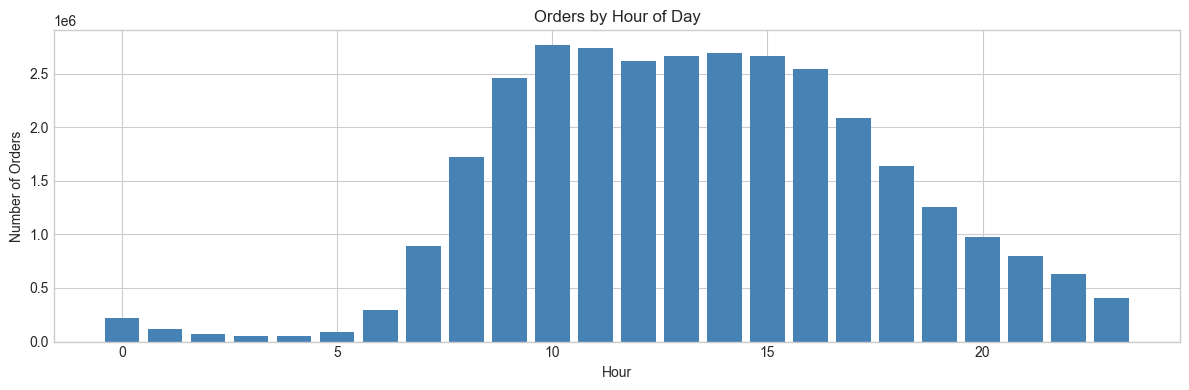

In [52]:
# ── Cell 8 — Hourly Demand Plot ───────────────────────────────────────
import matplotlib.pyplot as plt

hourly = df.groupby('order_hour_of_day').size()

plt.figure(figsize=(12, 4))
plt.bar(hourly.index, hourly.values, color='steelblue')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_hourly_demand.png', dpi=150)
print("Graph saved!")
plt.show()

Graph saved!


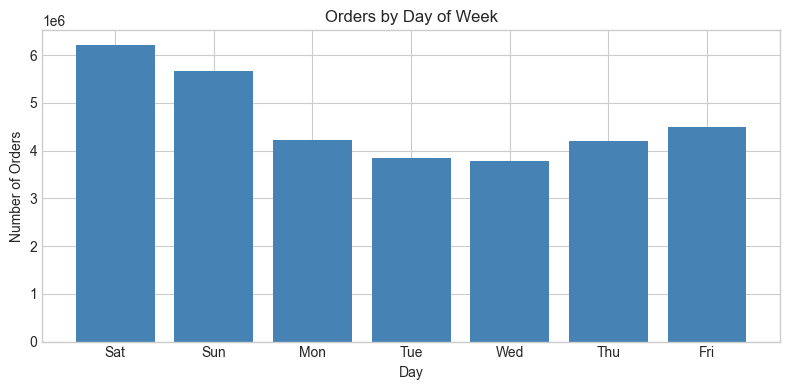

In [53]:
# ── Cell 9 — Orders by Day of Week ───────────────────────────────────
day_names = {0:'Sat',1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri'}

daily = df.groupby('order_dow').size()

plt.figure(figsize=(8, 4))
plt.bar(daily.index.map(day_names), daily.values, color='steelblue')
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_daily_demand.png', dpi=150)
print("Graph saved!")
plt.show()

Graph saved!


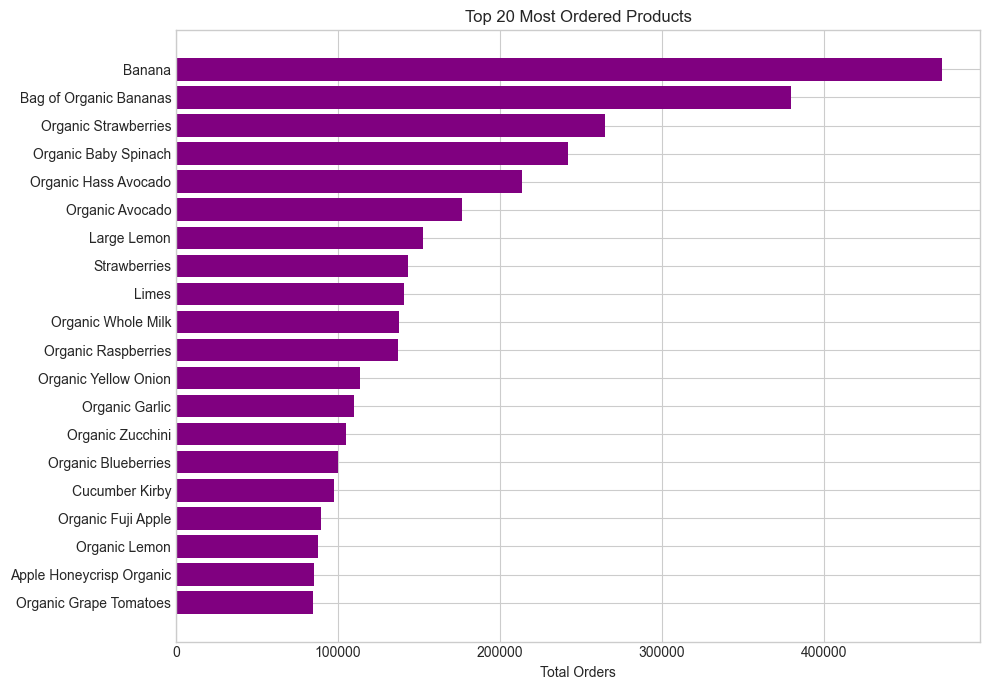

In [54]:
# ── Cell 10 — Top 20 Products ─────────────────────────────────────────
top20 = df.groupby('product_name').size().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(top20.index[::-1], top20.values[::-1], color='purple')
plt.title('Top 20 Most Ordered Products')
plt.xlabel('Total Orders')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_top_products.png', dpi=150)
print("Graph saved!")
plt.show()

Graph saved!


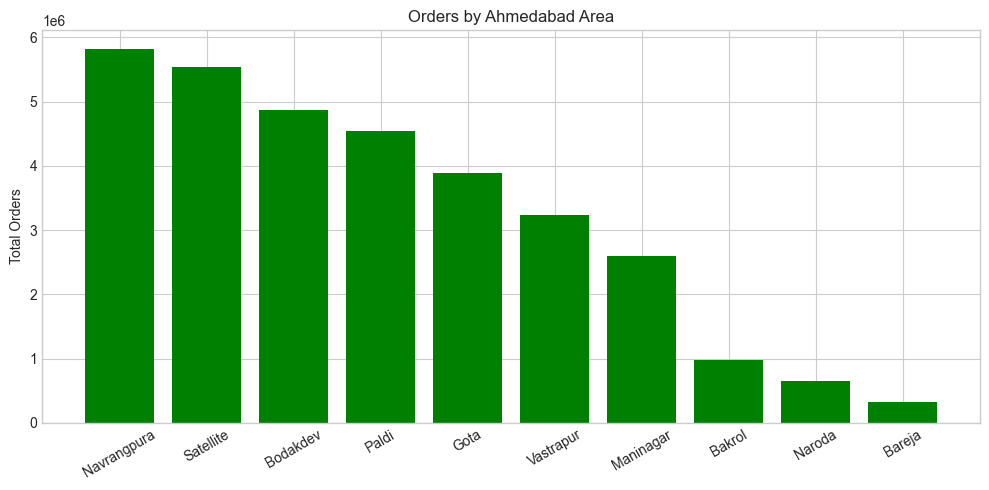

In [55]:
# ── Cell 11 — Orders by Area ──────────────────────────────────────────
area = df.groupby('area_name').size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(area.index, area.values, color='green')
plt.title('Orders by Ahmedabad Area')
plt.ylabel('Total Orders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_pincode_demand.png', dpi=150)
print("Graph saved!")
plt.show()

Graph saved!


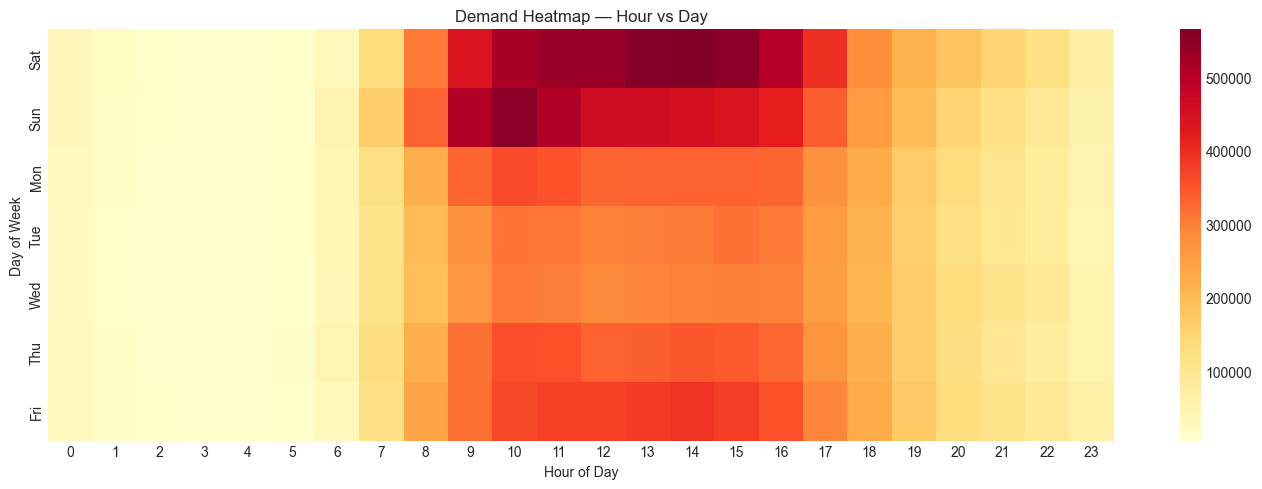

In [56]:
# ── Cell 12 — Heatmap Hour vs Day ────────────────────────────────────
import seaborn as sns

day_names = {0:'Sat',1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri'}

pivot = df.groupby(['order_dow','order_hour_of_day']).size().unstack(fill_value=0)
pivot.index = pivot.index.map(day_names)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Demand Heatmap — Hour vs Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_heatmap.png', dpi=150)
print("Graph saved!")
plt.show()

In [57]:
df.columns

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
       'eval_set', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'pincode', 'area_name', 'latitude',
       'longitude', 'product_name', 'aisle_id', 'department_id'],
      dtype='object')

Graph saved!


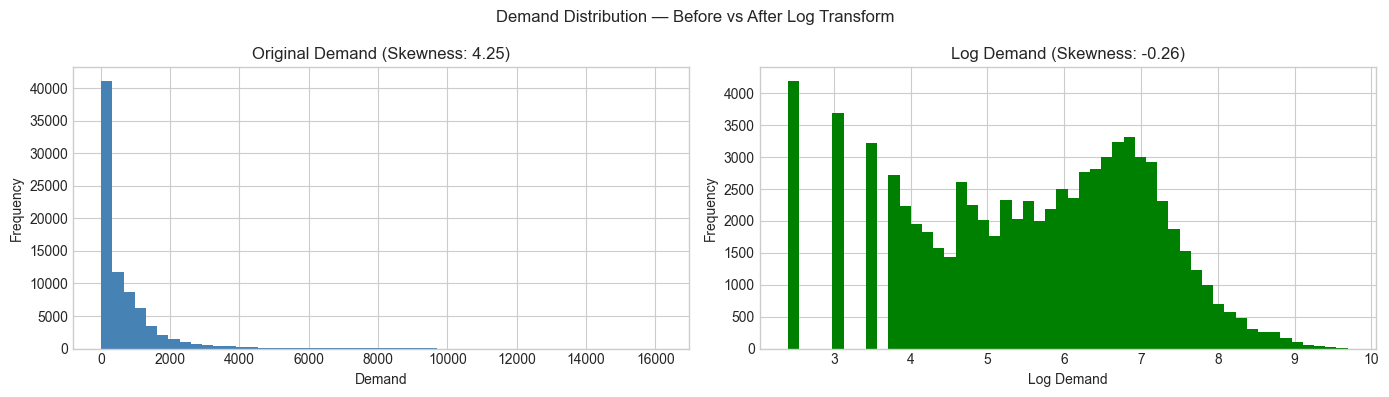

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before log transform
axes[0].hist(demand_df['demand'], bins=50, color='steelblue')
axes[0].set_title(f'Original Demand (Skewness: 4.25)')
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Frequency')

# After log transform
axes[1].hist(demand_df['demand_log'], bins=50, color='green')
axes[1].set_title(f'Log Demand (Skewness: -0.26)')
axes[1].set_xlabel('Log Demand')
axes[1].set_ylabel('Frequency')

plt.suptitle('Demand Distribution — Before vs After Log Transform')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_log_transform.png', dpi=150)
print("Graph saved!")
plt.show()

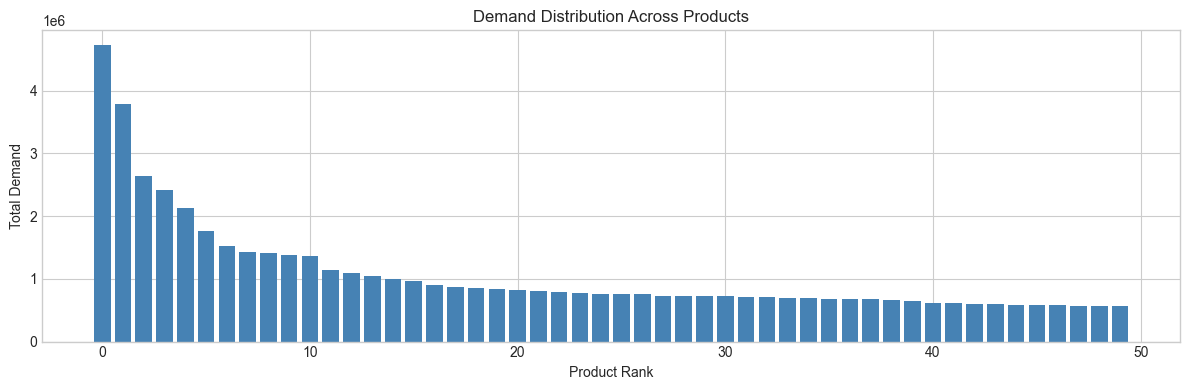

In [59]:
# ── Demand Distribution ───────────────────────────────────────────────
product_demand = demand_df.groupby('product_name')['demand'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
plt.bar(range(len(product_demand)), product_demand.values, color='steelblue')
plt.title('Demand Distribution Across Products')
plt.xlabel('Product Rank')
plt.ylabel('Total Demand')
plt.tight_layout()
plt.savefig(r'F:\projectss\personal\blinkit_project\noteboook\graph\plot_demand_skew.png', dpi=150)
plt.show()